## Fetch and Display NYSE Stock Data

### yfinance module 추가
nyse 종목

In [8]:
# _tsa_00.py
# time series stuff, basic
# 그리기
# 시계열, 추세, 계절성 조정, 이동평균, 이런 것들.
# 자기공분산, 자기상관, 단위근
# ARIMA 중 AR(p)
# 기타... 단순한 내용만 간략하게.

# 코랩 추가.
!pip install yfinance

import os
import numpy as np                          # numpy 라이브러리 전체.
import pandas as pd                         # pandas 라이브러리 전체, 시계열(기본) 여기 있네.
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf                       ## NYSE 데이터 모듈
from scipy import stats, optimize, linalg   # scipy 라이브러리 하부 모듈.
from statsmodels.tsa import stattools       # time series analysis
from statsmodels.tsa.arima.model import ARIMA # 이거 가능하다 이거지. 이거 대문자네. 꼭.
from statsmodels.tsa.ar_model import AutoReg


### Tesla TSLA series

In [9]:
# 1. 라이브러리 설치 (코랩의 경우 맨 앞에 ! 추가)
#!pip install yfinance
# import yfinance as yf # 앞에서 불렀음.

#ticker = 'TSLA'
ticker = 'HYNX'
# 테슬라(TSLA) 티커 지정 후 과거 5년치(5y) 데이터 호출
# (원하시면 기간을 '1y', '10y', 'max' 등으로 바꿀 수 있습니다)
df_dat = yf.download(ticker, period='5y', multi_level_index=False)
# df_tesla = yf.download('TSLA', period='5y')
# df_tesla = yf.download('TSLA', period='5y', multi_level_index=False)

# 3. 데이터프레임 확인 및 파일로 내보내기 (원할 때만)
df_dat.head()
#df_tesla.info()

# (만약 굳이 내 컴퓨터에 CSV 파일로 보관하고 싶다면 아래 주석 제거)
# df_dat.to_csv("tesla_historical_data.csv")


/tmp/ipykernel_2555/3933055788.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_dat = yf.download(ticker, period='5y', multi_level_index=False)
[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2026-07-14,38.770000,38.830002,29.490000,30.120001,776300
2026-07-15,31.620001,36.110001,27.709999,33.779999,1160300
2026-07-16,23.049999,28.629999,22.680000,27.950001,804900
2026-07-17,23.520000,27.469999,20.930000,22.980000,2235700
2026-07-20,22.580000,26.340000,22.150000,26.340000,1205200


### prices, volumes
level, differences, percentage changes

In [10]:
# NYSE daily stock prices and trading volumes
# 변수로 받는 방법.
yymmdd = df_dat.index   # 자료를 불러올 때, 자동으로 기준 인덱스로 설정된다고 함.
yymmdd = pd.to_datetime( yymmdd )

stck_prc = df_dat['Close']
stck_prc_dff = stck_prc.diff()
stck_prc_pct = stck_prc.pct_change()

stck_vlm = df_dat['Volume']
stck_vlm_dff = stck_vlm.diff()
stck_vlm_pct = stck_vlm.pct_change()


### time series plots
daily prices

Text(0.5, 1.0, ' Closing Prices of HYNX ')

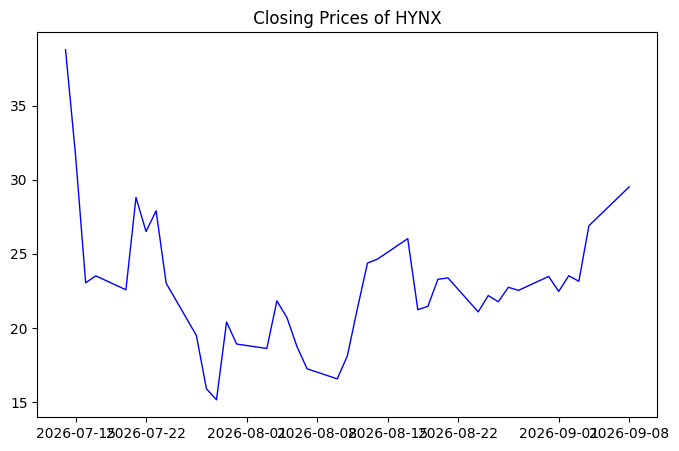

In [11]:

plt.figure(figsize=(8, 5))
#plt.subplot(figsize=(8,5  ))
plt.plot(yymmdd, stck_prc, color='blue', linewidth=1)
plt.title(f" Closing Prices of {ticker} ")


### daily changes in prices and volumes

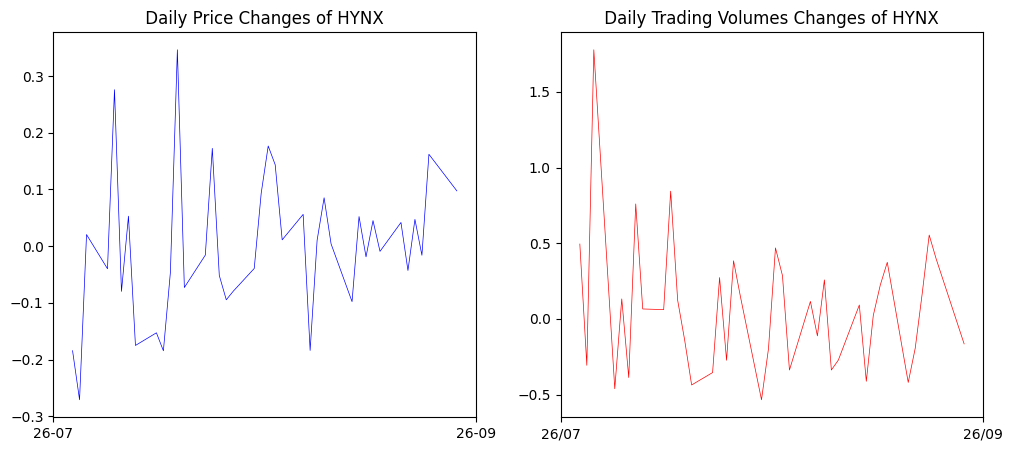

In [12]:

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
#axes[0].plot(yymmdd, stck_prc, color='blue', linewidth=0.5)
axes[0].plot(yymmdd, stck_prc_pct, color='blue', linewidth=0.5)
#axes[1].plot(yymmdd, stck_vlm, color='red', linewidth=0.5)
axes[1].plot(yymmdd, stck_vlm_pct, color='red', linewidth=0.5)
# axes[0].set_title(f" Closing Prices of {ticker} ")
axes[0].set_title(f" Daily Price Changes of {ticker} ")
axes[1].set_title(f" Daily Trading Volumes Changes of {ticker} ")
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=12))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=12))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%y/%m'))


### distibution of daily price changes

Text(0.5, 1.0, ' distribution of daily percentage change of HYNX ')

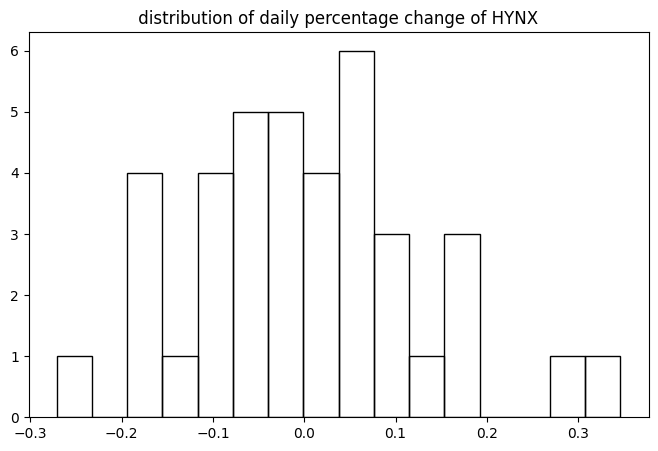

In [13]:

plt.figure(figsize=(8, 5))
plt.hist(stck_prc_pct, color='blue', linewidth=1, bins = 16, facecolor='None', edgecolor='black')
plt.title(f" distribution of daily percentage change of {ticker} ")
